In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip "/content/drive/MyDrive/AI_and_ML/ Week 5 - Introduction to CNN/FruitinAmazon.zip"

Archive:  /content/drive/MyDrive/AI_and_ML/ Week 5 - Introduction to CNN/FruitinAmazon.zip
  inflating: FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: FruitinAmazon/test/acai/images (2).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: FruitinAmazon/test/acai/images (16).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: FruitinAmazon/train/acai/images (3).jpeg  
  inflating: FruitinAmazon/train/acai/images (4).jpeg  
  inflating: FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (4).jpeg  
  inflating: FruitinAmazon/train/acai/images (11).jpeg  
  inflating: FruitinAmazon/test/tucuma/download (1).jpeg  
  inflating: FruitinAmazon/te

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

BASE_DIR= "/content/FruitinAmazon"
TRAIN_DIR= os.path.join(BASE_DIR, "train")
TEST_DIR= os.path.join(BASE_DIR, "test")

IMG_HEIGHT= 128
IMG_WIDTH= 128
BATCH_SIZE= 64
EPOCHS= 50
VAL_SPLIT= 0.2
SEED= 42

In [14]:
rescale = tf.keras.layers.Rescaling(1.0 / 255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
)
train_class_names = train_ds_raw.class_names
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)
test_class_names = test_ds_raw.class_names
# Apply the normalization (Rescaling) to the validation dataset
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

NUM_CLASSES = len(test_class_names)

print(f"Train classes : {train_class_names}")
print(f"Test  classes : {test_class_names}")
print(f"Number of output classes: {NUM_CLASSES}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Train classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test  classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of output classes: 6


In [16]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="Workshop5")

In [17]:
model.summary()


Model: "Workshop5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [19]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

In [20]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.2205 - loss: 1.9126
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 798ms/step - accuracy: 0.2222 - loss: 2.0252 - val_accuracy: 0.0000e+00 - val_loss: 2.4554
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2431 - loss: 2.1303
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 593ms/step - accuracy: 0.2361 - loss: 2.1559 - val_accuracy: 0.4444 - val_loss: 1.5223
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.3247 - loss: 1.7973
Epoch 3: val_accuracy improved from 0.44444 to 0.77778, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 566ms/step - accuracy: 0.3056 - loss: 1.8176 - val_accuracy: 0.777

In [21]:
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

print("True Labels:")
print(true_labels)

True Labels:
[np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(5), np.int32(5), np.int32(5), np.int32(5), np.int32(5)]


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions from the model on the test dataset
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Print Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_class_names))

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.71      1.00      0.83         5
     guarana       0.33      0.40      0.36         5
     pupunha       0.40      0.40      0.40         5
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.53        30
   macro avg       0.62      0.53      0.54        30
weighted avg       0.62      0.53      0.54        30

Confusion Matrix:
[[3 0 0 0 0 2]
 [0 2 1 0 0 2]
 [0 0 5 0 0 0]
 [0 0 0 2 2 1]
 [0 0 0 3 2 0]
 [0 0 1 1 1 2]]


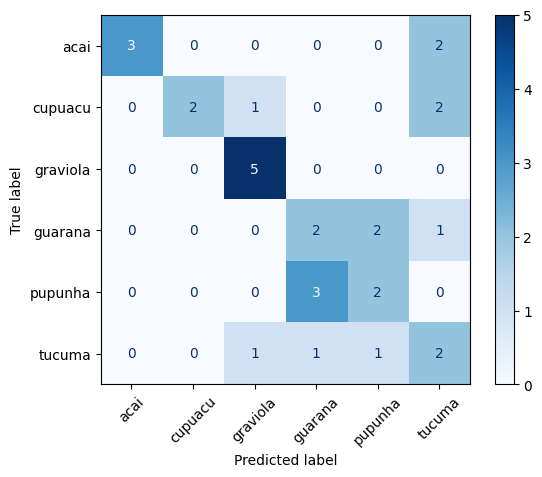

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    display_labels=test_class_names,
    cmap="Blues"
)
plt.xticks(rotation=45)
plt.show()